In [12]:
# EcoSort AI - Waste Classification

## MobileNetV2 Transfer Learning

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pathlib

In [14]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [9]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

NUM_CLASSES = 5

In [10]:
train_dir = pathlib.Path("../dataset/train")

validation_dir = pathlib.Path("../dataset/validation")

test_dir = pathlib.Path("../dataset/test")

In [11]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1671 files belonging to 5 classes.
Found 357 files belonging to 5 classes.
Found 362 files belonging to 5 classes.


In [12]:
class_names = train_dataset.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic']


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

test_dataset = test_dataset.prefetch(AUTOTUNE)

In [20]:
# Build MobileNetV2

In [14]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224, 224, 3),

    include_top=False,

    weights="imagenet"
)

In [15]:
base_model.trainable = False

In [23]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

In [24]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
# Data Augmentation

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [28]:
# Build Final Model

In [17]:
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

In [18]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [31]:
# Configure Callbacks

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [20]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "../backend/model/waste_classifier.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [5]:
# Train Model

In [21]:
EPOCHS = 20

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=EPOCHS,

    callbacks=[

        early_stopping,

        checkpoint

    ]

)

Epoch 1/20


c:\Users\AYAAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5901 - loss: 1.0410
Epoch 1: val_accuracy improved from None to 0.79832, saving model to ../backend/model/waste_classifier.keras

Epoch 1: finished saving model to ../backend/model/waste_classifier.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.5901 - loss: 1.0410 - val_accuracy: 0.7983 - val_loss: 0.5788
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7433 - loss: 0.6457
Epoch 2: val_accuracy improved from 0.79832 to 0.80672, saving model to ../backend/model/waste_classifier.keras

Epoch 2: finished saving model to ../backend/model/waste_classifier.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7433 - loss: 0.6457 - val_accuracy: 0.8067 - val_loss: 0.4930
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7959 - loss: 0.5287
Epoch 3: val_accuracy improved from 0.80672 to 0.84034, saving model to ../backend/model/waste_classifier.keras

Epoch 3: finished saving model to ../backend/mo

In [22]:
# Save Final Model

In [23]:
model.save("../backend/model/final_model.keras")

In [24]:
import os

os.path.exists("../backend/model/final_model.keras")

True

In [25]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [26]:
# Model Evaluation

In [27]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 653ms/step - accuracy: 0.8039 - loss: 0.4640
Test Loss: 0.4640
Test Accuracy: 0.8039


In [28]:
# Plot Training History

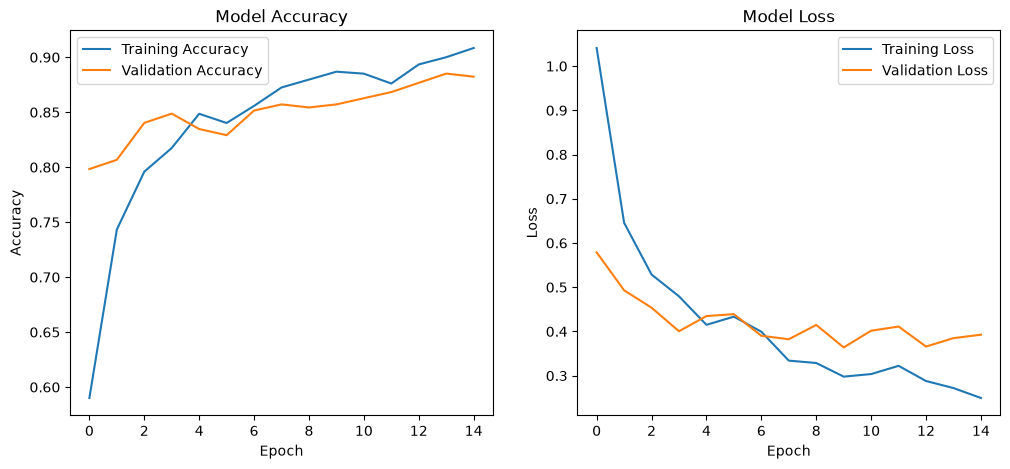

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [30]:
# Predictions

In [21]:
predictions = model.predict(test_dataset)

12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step


In [22]:
predicted_classes = predictions.argmax(axis=1)

In [23]:
import numpy as np

true_classes = []

for images, labels in test_dataset:
    true_classes.extend(labels.numpy())

true_classes = np.array(true_classes)

In [35]:
# Classification Report

In [2]:
from sklearn.metrics import classification_report

In [24]:
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   cardboard       0.16      0.41      0.23        61
       glass       0.00      0.00      0.00        76
       metal       0.15      0.44      0.22        62
       paper       0.11      0.02      0.04        90
     plastic       0.00      0.00      0.00        73

    accuracy                           0.15       362
   macro avg       0.08      0.17      0.10       362
weighted avg       0.08      0.15      0.09       362



In [25]:
# Confusion Matrix

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

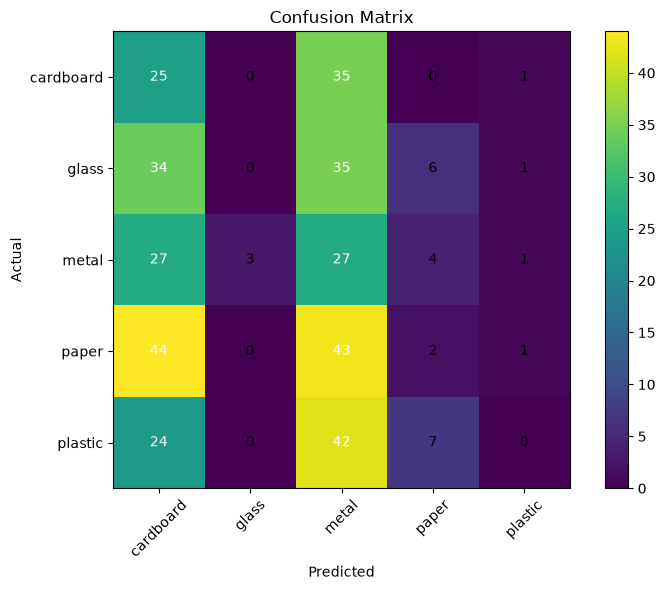

In [27]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )

plt.tight_layout()
plt.show()